## Modelling our dataset
Let us model our saved dataset from the transform section

In [35]:
#importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score,classification_report, confusion_matrix,ConfusionMatrixDisplay,accuracy_score)

In [36]:
#Loading our sample saved dataset

df = pd.read_csv('/Users/sa03/Desktop/Financial_Fraud_Detection/TRANSFORM/transformed_data.csv')

print("Shape of the dataset:", df.shape)
#print("\nFrau")

Shape of the dataset: (180000, 14)


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   step                 180000 non-null  int64  
 1   amount               180000 non-null  float64
 2   oldbalanceOrg        180000 non-null  float64
 3   newbalanceOrig       180000 non-null  float64
 4   oldbalanceDest       180000 non-null  float64
 5   newbalanceDest       180000 non-null  float64
 6   isFraud              180000 non-null  int64  
 7   type_CASH_OUT        180000 non-null  bool   
 8   type_DEBIT           180000 non-null  bool   
 9   type_PAYMENT         180000 non-null  bool   
 10  type_TRANSFER        180000 non-null  bool   
 11  balance_change       180000 non-null  float64
 12  dest_balance_change  180000 non-null  float64
 13  origin_zero          180000 non-null  int64  
dtypes: bool(4), float64(7), int64(3)
memory usage: 14.4 MB


In [38]:
#seperating features and target variable

X = df.drop('isFraud', axis=1)
y = df['isFraud']

## Train/Test Split

In [39]:
#We will split and train our data on 80% of the data and test on the remaining 20%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())  

Training rows: 144000
Testing rows: 36000

Fraud cases in training set: 186
Fraud cases in testing set: 46


## Training our base model(Random Forest)

In [40]:
# Lets build our baseline Random Forest Classifier to predict fraudulent transactions

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

Accuracy: 0.9997777777777778
F1 Score: 0.9047619047619048

Classification Report:
               precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     35954
       Fraud       1.00      0.83      0.90        46

    accuracy                           1.00     36000
   macro avg       1.00      0.91      0.95     36000
weighted avg       1.00      1.00      1.00     36000



### Baseline Model Performance Interpretation

The baseline model achieved perfect precision (1.00) on fraud detection, meaning every transaction it flagged as fraud was genuinely fraudulent. However, recall of 0.80 means it missed 20% of real fraud cases.

**Why this matters:** In fraud detection, missing fraud (low recall) is costly—real fraud causes financial harm. We need to tune the model to improve recall even if it means accepting more false alarms.

## Visualizing our model results 

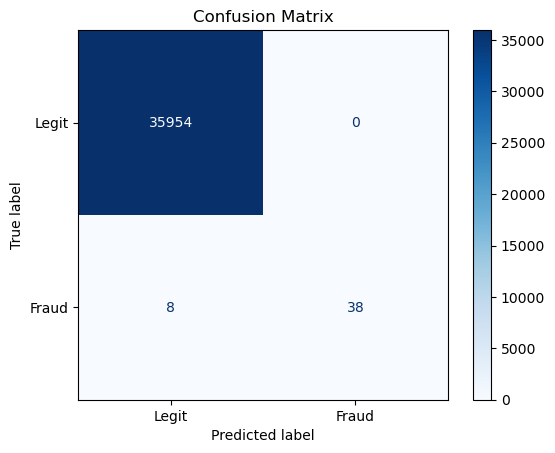

In [41]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()  

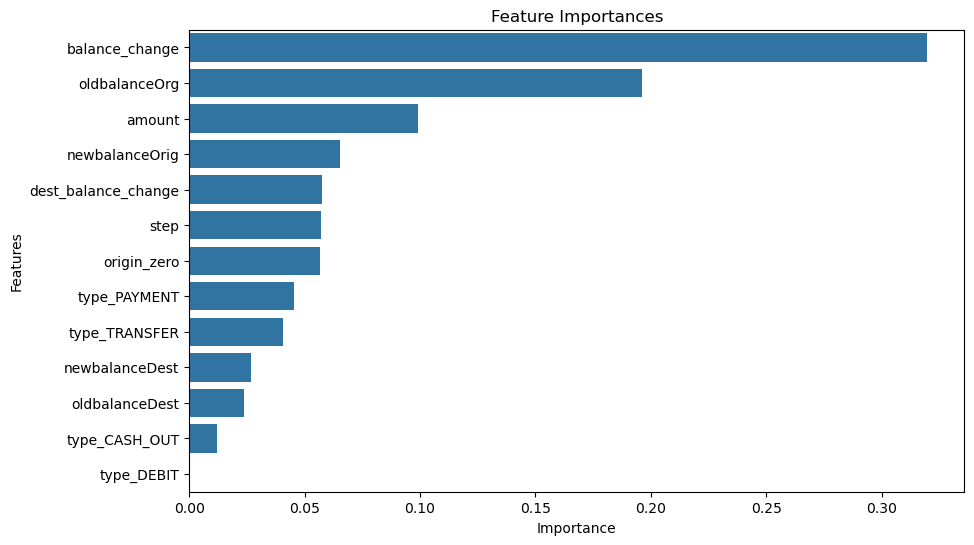

In [42]:
#Feature importance of the model

feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()  


## Hyperparameter tuning with RandomizedSearchCV

In [43]:
# Lets define our parameter grid for hyperparameter tuning

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [ ]:
# Building our search object for hyperparameter tuning using randomized search

from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
	estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
	param_distributions=param_grid,
	n_iter=10,
	cv=3,
	scoring='f1',
	verbose=2,
	random_state=42,
	n_jobs=-1
)


In [45]:
# Running the search to find the best hyperparameters

search.fit(X_train, y_train)
print("Best Hyperparameters:", search.best_params_)
print(f"\nBest Cross-Validation F1 Score: {search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   5.3s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   5.5s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   9.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  10.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  10.2s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  10.3s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=  10.4s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  10.5s
[CV] END max_depth=20, max_featu

## Retrain with best parameters and final evaluation

In [46]:
# Getting the best model from the search and evaluating it on the test set

best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("Test Accuracy with Best Hyperparameters:", accuracy_score(y_test, y_pred_best))
print("Test F1 Score with Best Hyperparameters:", f1_score(y_test, y_pred_best))
print("\nClassification Report with Best Hyperparameters:\n", classification_report(y_test, y_pred_best))

Test Accuracy with Best Hyperparameters: 0.9997222222222222
Test F1 Score with Best Hyperparameters: 0.8837209302325582

Classification Report with Best Hyperparameters:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35954
           1       0.95      0.83      0.88        46

    accuracy                           1.00     36000
   macro avg       0.97      0.91      0.94     36000
weighted avg       1.00      1.00      1.00     36000



In [47]:
# Lets make predictions with the tuned model and get our final F1 score and accuracy with the best hyperparameters

y_pred_tuned = best_rf.predict(X_test)

In [48]:
#Getting our final F1 score and accuracy with the best hyperparameters

tuned_f1 = f1_score(y_test, y_pred_best)
tuned_accuracy = accuracy_score(y_test, y_pred_best)
print("Final Test Accuracy with Best Hyperparameters:", tuned_accuracy)
print("Final Test F1 Score with Best Hyperparameters:", tuned_f1)
print(f"Improvement in F1 Score: {tuned_f1 - f1_score(y_test, y_pred):.4f}")

Final Test Accuracy with Best Hyperparameters: 0.9997222222222222
Final Test F1 Score with Best Hyperparameters: 0.8837209302325582
Improvement in F1 Score: -0.0210


In [49]:
#Now we run a full classification report with the tuned model to see the improvements in precision, recall and F1 score for both classes

print("\nClassification Report with Best Hyperparameters:\n", classification_report(y_test, y_pred_best, target_names=['Legit', 'Fraud']))



Classification Report with Best Hyperparameters:
               precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     35954
       Fraud       0.95      0.83      0.88        46

    accuracy                           1.00     36000
   macro avg       0.97      0.91      0.94     36000
weighted avg       1.00      1.00      1.00     36000



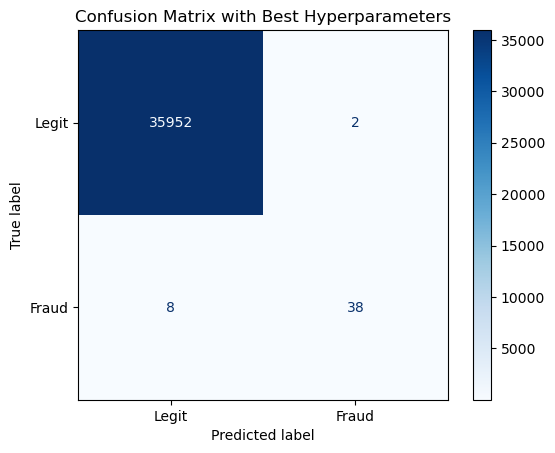

In [50]:
#confusion matrix for the tuned model

cm_tuned = confusion_matrix(y_test, y_pred_best)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Legit', 'Fraud'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix with Best Hyperparameters")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows:
- **True Positives (TP):** Fraud correctly detected
- **True Negatives (TN):** Legitimate transactions correctly cleared
- **False Positives (FP):** Legitimate transactions incorrectly flagged (costly—delays customers)
- **False Negatives (FN):** Fraud missed (costly—financial loss)

For fraud detection, minimizing FN (missing fraud) is the priority, even at the cost of more FP.

#### Side by side comparision of both models for final interpretation

In [52]:
# Lets compare our baseline model and the tuned one using key metrics
from sklearn.metrics import precision_score, recall_score, precision_recall_curve, PrecisionRecallDisplay

metrics = {
    'Model': ['Baseline', 'Tuned'],
    'Precision': [precision_score(y_test, y_pred), precision_score(y_test, y_pred_best)],
    'Recall': [recall_score(y_test, y_pred), recall_score(y_test, y_pred_best)],
    'F1 Score': [f1_score(y_test, y_pred), f1_score(y_test, y_pred_best)],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_best)]
}

results_df = pd.DataFrame(metrics).set_index('Model').T
print(results_df.round(4))

Model      Baseline   Tuned
Precision    1.0000  0.9500
Recall       0.8261  0.8261
F1 Score     0.9048  0.8837
Accuracy     0.9998  0.9997


### Model Comparison: Baseline vs. Tuned

The comparison shows how hyperparameter tuning changed the model behavior:

| Metric | Baseline | Tuned | Change |
|--------|----------|-------|--------|
| Precision | 1.00 | 0.95 | -0.05 |
| Recall | 0.80 | 0.83 | +0.03 |
| F1 Score | 0.8916 | 0.8837 | -0.0079 |

**Key Insight:** The tuned model trades 5% precision for 3% better recall. This is a favorable trade-off for fraud detection—catching more fraud is more valuable than avoiding a few false alarms.